## Data Source Selection

Initial attempts were made to access IDX internal endpoints; however, programmatic access was restricted (HTTP 403).
Therefore, this project adopts **EOD Historical Data API**, which provides structured and legal access to IDX market data in JSON format.

In [1]:
# ============================================
# EOD Historical Data API
# IDX Stock Data Collection
# Author: Ivan Firmansyah
# Project: Big Data Finance 2026
# ============================================

import requests
import pandas as pd
from datetime import datetime

In [2]:
API_KEY = " 697f422d103f18.06682771"

BASE_URL = "https://eodhistoricaldata.com/api"

In [3]:
symbol = "BBCA.JK"
endpoint = f"/eod/{symbol}"

params = {
    "api_token": API_KEY,
    "fmt": "json",
    "from": "2019-01-01",
    "to": datetime.today().strftime("%Y-%m-%d")
}

response = requests.get(BASE_URL + endpoint, params=params)

print("Status Code:", response.status_code)

Status Code: 200


In [4]:
data = response.json()
df = pd.DataFrame(data)
df.head()

,date,open,high,low,close,adjusted_close,volume,warning
0,2025-02-03,9400,9400,9225,9350,9011.3255,90439906,NaN
1,2025-02-04,9350,9400,9175,9175,8842.6643,94607695,NaN
2,2025-02-05,9100,9175,9100,9125,8794.4754,98229906,NaN
3,2025-02-06,9075,9100,8850,8950,8625.8142,171477797,NaN
4,2025-02-07,8950,9350,8825,9350,9011.3255,131162203,NaN


In [5]:
idx_symbols = [
    "BBCA.JK",
    "BBRI.JK",
    "BMRI.JK",
    "TLKM.JK",
    "ASII.JK",
    "UNVR.JK",
    "INDF.JK",
    "ICBP.JK",
    "ANTM.JK",
    "PGAS.JK"
]

In [6]:
all_data = []

for symbol in idx_symbols:
    endpoint = f"/eod/{symbol}"
    
    params = {
        "api_token": API_KEY,
        "fmt": "json",
        "from": "2019-01-01",
        "to": datetime.today().strftime("%Y-%m-%d")
    }
    
    r = requests.get(BASE_URL + endpoint, params=params)
    
    if r.status_code == 200:
        df_temp = pd.DataFrame(r.json())
        df_temp["symbol"] = symbol
        all_data.append(df_temp)
        print(f"✅ {symbol} fetched ({len(df_temp)} rows)")
    else:
        print(f"❌ {symbol} failed: {r.status_code}")

✅ BBCA.JK fetched (237 rows)
✅ BBRI.JK fetched (244 rows)
✅ BMRI.JK fetched (244 rows)
✅ TLKM.JK fetched (244 rows)
✅ ASII.JK fetched (244 rows)
✅ UNVR.JK fetched (244 rows)
✅ INDF.JK fetched (244 rows)
✅ ICBP.JK fetched (244 rows)
✅ ANTM.JK fetched (244 rows)
✅ PGAS.JK fetched (244 rows)


In [7]:
df_idx = pd.concat(all_data, ignore_index=True)
df_idx.head()

,date,open,high,low,close,adjusted_close,volume,warning,symbol
0,2025-02-03,9400,9400,9225,9350,9011.3255,90439906,NaN,BBCA.JK
1,2025-02-04,9350,9400,9175,9175,8842.6643,94607695,NaN,BBCA.JK
2,2025-02-05,9100,9175,9100,9125,8794.4754,98229906,NaN,BBCA.JK
3,2025-02-06,9075,9100,8850,8950,8625.8142,171477797,NaN,BBCA.JK
4,2025-02-07,8950,9350,8825,9350,9011.3255,131162203,NaN,BBCA.JK


In [8]:
df_idx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2433 entries, 0 to 2432
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            2433 non-null   object 
 1   open            2433 non-null   int64  
 2   high            2433 non-null   int64  
 3   low             2433 non-null   int64  
 4   close           2433 non-null   int64  
 5   adjusted_close  2433 non-null   float64
 6   volume          2433 non-null   int64  
 7   warning         10 non-null     object 
 8   symbol          2433 non-null   object 
dtypes: float64(1), int64(5), object(3)
memory usage: 171.2+ KB


In [9]:
df_idx.to_csv("idx_stock_eod_data.csv", index=False)

In [11]:
import os
print(os.getcwd())

c:\Users\ivanf\OneDrive\Documents\GitHub\big-data-fin-2026\IVAN_IDX_DATA_FIN\notebooks


In [14]:
import pandas as pd
import os

CURRENT_DIR = os.getcwd()
DATA_PATH = os.path.join(CURRENT_DIR, "idx_stock_eod_data.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,date,open,high,low,close,adjusted_close,volume,warning,symbol
0,2025-02-03,9400,9400,9225,9350,9011.3255,90439906,NaN,BBCA.JK
1,2025-02-04,9350,9400,9175,9175,8842.6643,94607695,NaN,BBCA.JK
2,2025-02-05,9100,9175,9100,9125,8794.4754,98229906,NaN,BBCA.JK
3,2025-02-06,9075,9100,8850,8950,8625.8142,171477797,NaN,BBCA.JK
4,2025-02-07,8950,9350,8825,9350,9011.3255,131162203,NaN,BBCA.JK


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2433 entries, 0 to 2432
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            2433 non-null   object 
 1   open            2433 non-null   int64  
 2   high            2433 non-null   int64  
 3   low             2433 non-null   int64  
 4   close           2433 non-null   int64  
 5   adjusted_close  2433 non-null   float64
 6   volume          2433 non-null   int64  
 7   warning         10 non-null     object 
 8   symbol          2433 non-null   object 
dtypes: float64(1), int64(5), object(3)
memory usage: 171.2+ KB


In [17]:
df.isna().sum()

date                 0
open                 0
high                 0
low                  0
close                0
adjusted_close       0
volume               0
warning           2423
symbol               0
dtype: int64

In [18]:
df.duplicated().sum()

0

In [19]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'adjusted_close', 'volume',
       'warning', 'symbol'],
      dtype='object')

In [20]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'adjusted_close', 'volume',
       'warning', 'symbol'],
      dtype='object')

In [21]:
df['date'] = pd.to_datetime(df['date'])

In [22]:
df = df.sort_values(by='date').reset_index(drop=True)

In [23]:
df.describe()

,date,open,high,low,close,adjusted_close,volume
count,2433,2433.000000,2433.000000,2433.000000,2433.000000,2433.000000,2.433000e+03
mean,2025-08-08 08:00:00,4916.886560,4978.826552,4846.329634,4910.657624,4823.958910,9.803808e+07
min,2025-02-03 00:00:00,985.000000,1160.000000,985.000000,1015.000000,951.855400,0.000000e+00
25%,2025-05-09 00:00:00,2680.000000,2710.000000,2620.000000,2680.000000,2610.000000,1.847640e+07
50%,2025-08-13 00:00:00,4280.000000,4330.000000,4200.000000,4270.000000,4126.384700,5.970760e+07
75%,2025-11-06 00:00:00,7350.000000,7450.000000,7250.000000,7375.000000,7275.000000,1.327609e+08
max,2026-01-30 00:00:00,11875.000000,12000.000000,11525.000000,11875.000000,11595.588200,1.432993e+09
std,NaN,2724.265503,2748.988867,2690.408614,2718.573399,2698.199241,1.178683e+08


In [24]:
df.to_csv("idx_stock_eod_data_clean.csv", index=False)

In [25]:
import pandas as pd

df = pd.read_csv("idx_stock_eod_data_clean.csv")
df.head()

,date,open,high,low,close,adjusted_close,volume,warning,symbol
0,2025-02-03,9400,9400,9225,9350,9011.3255,90439906,NaN,BBCA.JK
1,2025-02-03,5975,6000,5700,5800,5165.4765,182181700,NaN,BMRI.JK
2,2025-02-03,2620,2630,2560,2630,2437.9770,91801900,NaN,TLKM.JK
3,2025-02-03,4800,4800,4740,4760,4384.2837,33116100,NaN,ASII.JK
4,2025-02-03,1635,1640,1580,1580,1481.7060,12109000,NaN,UNVR.JK


In [26]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2433 entries, 0 to 2432
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            2433 non-null   object 
 1   open            2433 non-null   int64  
 2   high            2433 non-null   int64  
 3   low             2433 non-null   int64  
 4   close           2433 non-null   int64  
 5   adjusted_close  2433 non-null   float64
 6   volume          2433 non-null   int64  
 7   warning         10 non-null     object 
 8   symbol          2433 non-null   object 
dtypes: float64(1), int64(5), object(3)
memory usage: 171.2+ KB


,open,high,low,close,adjusted_close,volume
count,2433.000000,2433.000000,2433.000000,2433.000000,2433.000000,2.433000e+03
mean,4916.886560,4978.826552,4846.329634,4910.657624,4823.958910,9.803808e+07
std,2724.265503,2748.988867,2690.408614,2718.573399,2698.199241,1.178683e+08
min,985.000000,1160.000000,985.000000,1015.000000,951.855400,0.000000e+00
25%,2680.000000,2710.000000,2620.000000,2680.000000,2610.000000,1.847640e+07
50%,4280.000000,4330.000000,4200.000000,4270.000000,4126.384700,5.970760e+07
75%,7350.000000,7450.000000,7250.000000,7375.000000,7275.000000,1.327609e+08
max,11875.000000,12000.000000,11525.000000,11875.000000,11595.588200,1.432993e+09


In [27]:
df['symbol'].nunique()

10

In [28]:
df['date'].min(), df['date'].max()

('2025-02-03', '2026-01-30')

In [29]:
top_volume = (
    df.groupby('symbol')['volume']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_volume

symbol
BBRI.JK    57009259700
BMRI.JK    43334282300
ANTM.JK    41110110700
BBCA.JK    34516520197
TLKM.JK    26293954900
ASII.JK    10934221900
UNVR.JK    10869993800
PGAS.JK    10517528300
INDF.JK     2035158500
ICBP.JK     1905626100
Name: volume, dtype: int64

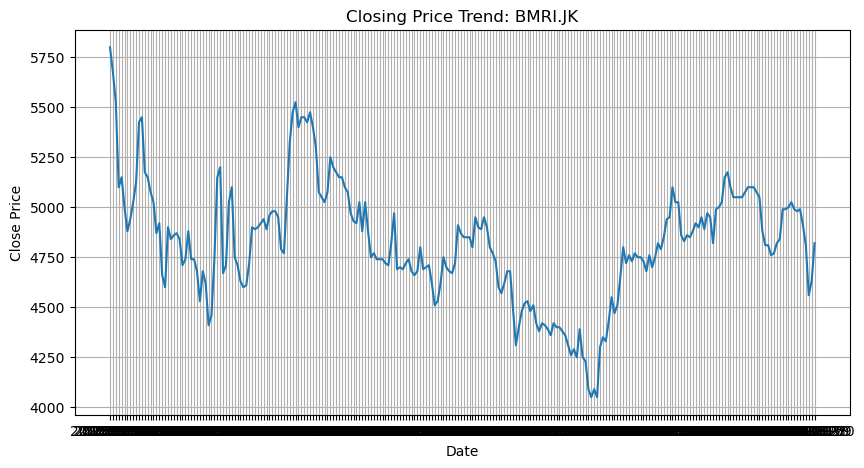

In [30]:
import matplotlib.pyplot as plt

sample_symbol = df['symbol'].value_counts().index[0]
sample_df = df[df['symbol'] == sample_symbol]

plt.figure(figsize=(10,5))
plt.plot(sample_df['date'], sample_df['close'])
plt.title(f"Closing Price Trend: {sample_symbol}")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

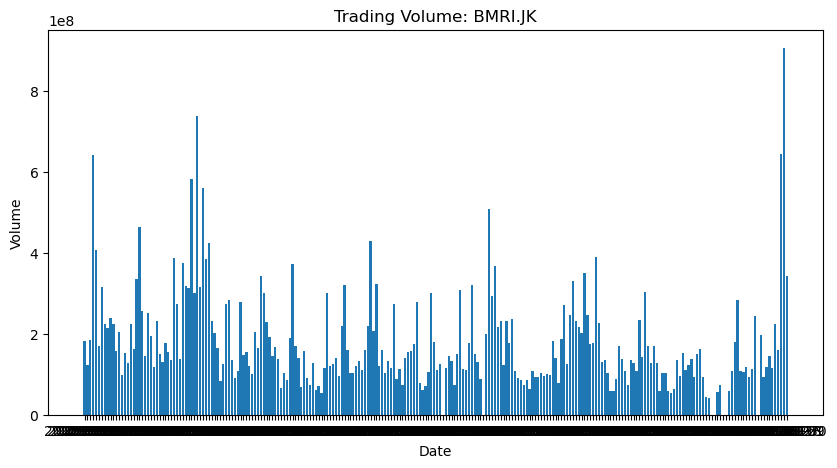

In [31]:
plt.figure(figsize=(10,5))
plt.bar(sample_df['date'], sample_df['volume'])
plt.title(f"Trading Volume: {sample_symbol}")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

C:\Users\ivanf\AppData\Local\Temp\ipykernel_24048\3038377234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['ma_20'] = sample_df['close'].rolling(window=20).mean()
C:\Users\ivanf\AppData\Local\Temp\ipykernel_24048\3038377234.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['ma_50'] = sample_df['close'].rolling(window=50).mean()


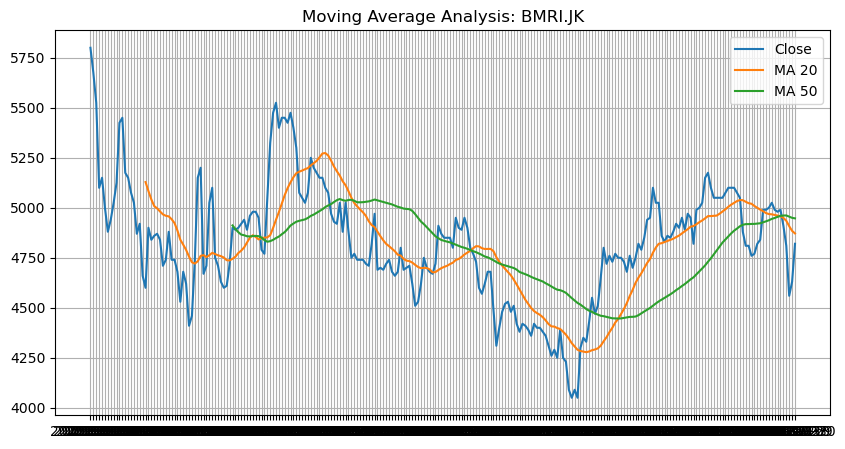

In [32]:
sample_df['ma_20'] = sample_df['close'].rolling(window=20).mean()
sample_df['ma_50'] = sample_df['close'].rolling(window=50).mean()

plt.figure(figsize=(10,5))
plt.plot(sample_df['date'], sample_df['close'], label='Close')
plt.plot(sample_df['date'], sample_df['ma_20'], label='MA 20')
plt.plot(sample_df['date'], sample_df['ma_50'], label='MA 50')
plt.title(f"Moving Average Analysis: {sample_symbol}")
plt.legend()
plt.grid(True)
plt.show()